# **Análise de Dados - Portal da Transparência**

In [1]:
from pathlib import Path

# Caminhos relativos à pasta do projeto
caminho_dados = Path('data/2023_Viagem.csv')
caminho_saida_tabela = Path('output/tabela_2023.xlsx')
caminho_saida_grafico = Path('output/grafico_2023.png')

caminho_dados.parent.mkdir(exist_ok=True)
caminho_saida_tabela.parent.mkdir(exist_ok=True)

# Se o CSV ainda não estiver na pasta data/, baixa do Google Drive
if not caminho_dados.exists():
    import gdown
    gdown.download(id='18j80hFqWkKMRyWGm_Jol539dX0Z0Vkoz', output=str(caminho_dados), quiet=False)

if not caminho_dados.exists():
    raise FileNotFoundError(
        f"Não foi possível baixar {caminho_dados}. Verifique sua conexão e tente executar a célula novamente."
    )

Downloading...
From (original): https://drive.google.com/uc?id=18j80hFqWkKMRyWGm_Jol539dX0Z0Vkoz
From (redirected): https://drive.google.com/uc?id=18j80hFqWkKMRyWGm_Jol539dX0Z0Vkoz&confirm=t&uuid=51eb23a4-e730-4c86-9889-1f4db4ade393
To: /content/data/2023_Viagem.csv
100%|██████████| 496M/496M [00:05<00:00, 99.0MB/s]


In [2]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Lendo os Dados
df_viagens = pd.read_csv(caminho_dados, encoding ='Windows-1252', sep=';', decimal=",")

# Criando nova coluna de despesas
df_viagens['Despesas'] = df_viagens['Valor diárias'] + df_viagens['Valor passagens'] + df_viagens['Valor outros gastos']

#Ajustando valores nulos na coluna de cargo
df_viagens['Cargo'] = df_viagens['Cargo'].fillna("NÃO IDENTIFICADO")

#Convertendo colunas de datas
df_viagens["Período - Data de início"] = pd.to_datetime(df_viagens["Período - Data de início"], format="%d/%m/%Y")
df_viagens["Período - Data de fim"] = pd.to_datetime(df_viagens["Período - Data de fim"], format="%d/%m/%Y")

#Criando novas colunas de dados
df_viagens['Mês da viagem'] = df_viagens['Período - Data de início'].dt.month_name()
df_viagens['Dias de viagem'] = (df_viagens['Período - Data de fim'] - df_viagens ['Período - Data de início']).dt.days

In [3]:
# Criando tabela consolidada
df_viagens_consolidado = (
    df_viagens
    .groupby('Cargo')
    .agg(
        despesa_media=('Despesas', 'mean'),
        duracao_media=('Dias de viagem', 'mean'),
        despesas_totais=('Despesas', 'sum'),
        destino_mais_frequente=("Destinos", pd.Series.mode),
        n_viagens=('Nome', 'count')
        )
  .reset_index()
    )

# Filtrando tabela consolidada por cargos relevantes(> 1% das viagens)
df_cargos = df_viagens['Cargo'].value_counts(normalize=True).reset_index()
cargos_relevantes = df_cargos.loc[df_cargos['proportion'] > 0.01, 'Cargo']
filtro = df_viagens_consolidado['Cargo'].isin(cargos_relevantes)

# Chegando na tabela final - consolidada e filtrada
df_final = df_viagens_consolidado[filtro].sort_values(by='n_viagens', ascending=False)

# Salvando a tabela final
df_final.to_excel(caminho_saida_tabela)

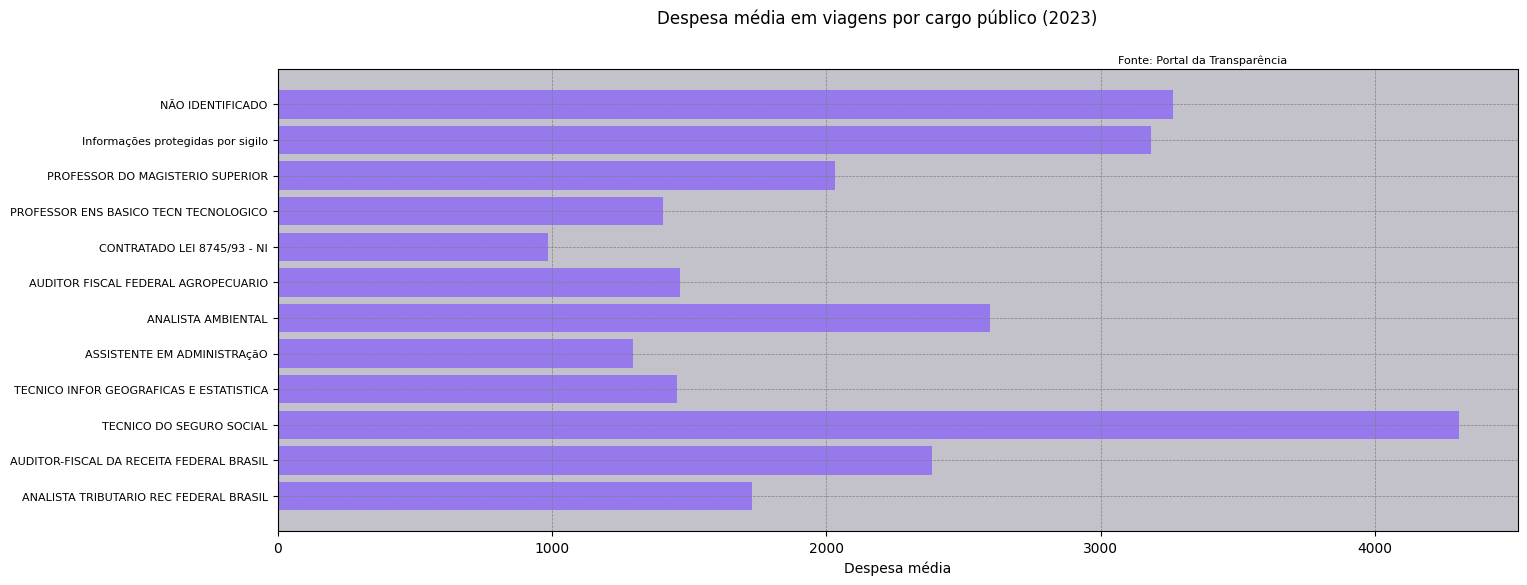

In [4]:
import matplotlib.pyplot as plt

# Criando a figura
fig, ax = plt.subplots(figsize=(16, 6))

# Plotando o Gráfico
ax.barh(df_final['Cargo'], df_final['despesa_media'], color='#9679ed')
ax.invert_yaxis()

#Ajustando o gráfico
ax.set_facecolor('#c3c1c9')
fig.suptitle('Despesa média em viagens por cargo público (2023)')
plt.figtext(0.65, 0.89, 'Fonte: Portal da Transparência', fontsize=8)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.yticks(fontsize=8)
plt.xlabel('Despesa média')

# Salvando o gráfico
plt.savefig(caminho_saida_grafico, bbox_inches='tight')